<a href="https://colab.research.google.com/github/prayag-1771/Fake_News_Pattern_Analysis/blob/main/Fake_News_Pattern_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title: Fake News Detection and Sentiment Pattern Analysis using Text Mining

Objective:
The goal of this project is to analyze textual data and identify patterns
associated with misleading information. Text mining techniques and machine
learning are used to detect fake news. Additionally, sentiment analysis
is performed to study emotional patterns present in the text.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
df.shape

(31962, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [5]:
df['text_length'] = df['tweet'].apply(len)

df.head()

,id,label,tweet,text_length
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


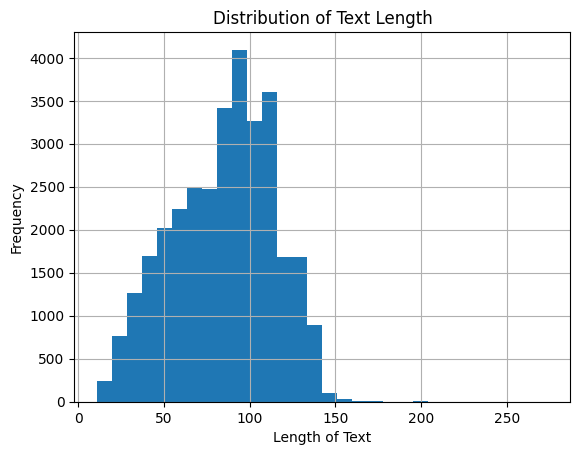

In [6]:
df['text_length'].hist(bins=30)

plt.title("Distribution of Text Length")
plt.xlabel("Length of Text")
plt.ylabel("Frequency")

plt.show()

In [7]:
df['label'].value_counts()

,count
label,
0,29720
1,2242


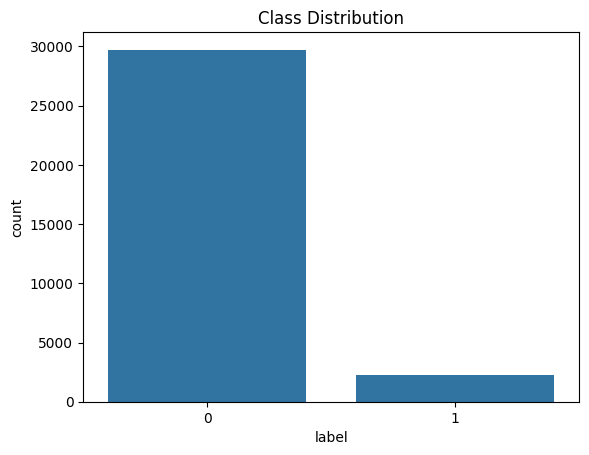

In [8]:
sns.countplot(x=df['label'])

plt.title("Class Distribution")

plt.show()

In [9]:
!pip install textblob

In [10]:
from textblob import TextBlob

df['sentiment_score'] = df['tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)

df[['tweet','sentiment_score']].head()

,tweet,sentiment_score
0,@user when a father is dysfunctional and is s...,-0.500000
1,@user @user thanks for #lyft credit i can't us...,0.200000
2,bihday your majesty,0.000000
3,#model i love u take with u all the time in ...,0.976562
4,factsguide: society now #motivation,0.000000


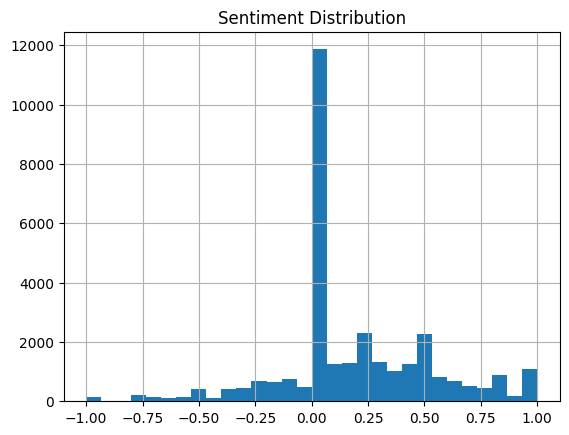

In [11]:
df['sentiment_score'].hist(bins=30)

plt.title("Sentiment Distribution")

plt.show()

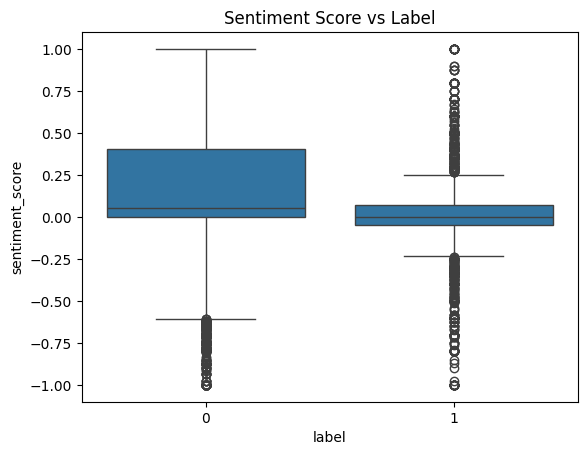

In [12]:
sns.boxplot(x='label', y='sentiment_score', data=df)

plt.title("Sentiment Score vs Label")

plt.show()

In [13]:
words = " ".join(df['tweet']).lower().split()

Counter(words).most_common(15)

[('@user', 17291),
 ('the', 10065),
 ('to', 9768),
 ('a', 6261),
 ('i', 5655),
 ('you', 4949),
 ('and', 4831),
 ('in', 4570),
 ('for', 4435),
 ('of', 4152),
 ('is', 4102),
 ('my', 3626),
 ('on', 2554),
 ('with', 2482),
 ('this', 2462)]

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['tweet'])

y = df['label']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [18]:
pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.9591740966682308

Conclusion

This project analyzed textual data using text mining and machine learning
techniques to detect misleading information. Sentiment analysis was also
performed to examine emotional patterns in the text. The classification
model successfully identified patterns that help distinguish between
different classes of information.